# Imports

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import time

# Download ECG5000

In [14]:
# ECG5000 is available directly from UCR archive
!wget -q "https://www.timeseriesclassification.com/aeon-toolkit/ECG5000.zip"
!unzip -q ECG5000.zip

# Load
train = pd.read_csv("ECG5000_TRAIN.txt", header=None, sep=r'\s+')
test  = pd.read_csv("ECG5000_TEST.txt",  header=None, sep=r'\s+')

# First column is label, rest is signal
X_train = train.iloc[:, 1:].values.astype(np.float32)
y_train = train.iloc[:, 0].values
X_test  = test.iloc[:, 1:].values.astype(np.float32)
y_test  = test.iloc[:, 0].values

# Encode labels to 0-indexed
le = LabelEncoder()
y_train = le.fit_transform(y_train).astype(np.int64)
y_test  = le.transform(y_test).astype(np.int64)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Sequence length: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y_train))}")

replace ECG5000.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: yA
replace ECG5000_TEST.arff? [y]es, [n]o, [A]ll, [N]one, [r]ename: yA
replace ECG5000_TEST.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Train: (500, 140), Test: (4500, 140)
Sequence length: 140
Classes: 5


# Normalize and build DataLoaders

In [15]:
# Normalize per sample (zero mean, unit variance)
mean = X_train.mean(axis=1, keepdims=True)
std  = X_train.std(axis=1, keepdims=True) + 1e-8
X_train = (X_train - mean) / std

mean = X_test.mean(axis=1, keepdims=True)
std  = X_test.std(axis=1, keepdims=True) + 1e-8
X_test = (X_test - mean) / std

# Add channel dimension → (batch, 1, T)
X_train = torch.tensor(X_train).unsqueeze(1)
X_test  = torch.tensor(X_test).unsqueeze(1)
y_train = torch.tensor(y_train)
y_test  = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test),  batch_size=32, shuffle=False)

print(f"Input shape: {X_train.shape}")

Input shape: torch.Size([500, 1, 140])


In [16]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(789)

# CNN + temporal pooling

In [17]:
class CNN_TemporalPooling(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.network(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x)

# CNN + LSTM

In [18]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=128,
                            num_layers=2, batch_first=True)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)           # (batch, 128, T)
        x = x.permute(0, 2, 1)   # (batch, T, 128)
        _, (h_n, _) = self.lstm(x)
        x = h_n[-1]               # last layer hidden state
        return self.classifier(x)

# Training

In [19]:
def train_model(model, train_loader, test_loader, epochs=50, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_accuracies = [], []
    start = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Evaluate
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                preds = model(X_batch).argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y_batch.numpy())

        acc = accuracy_score(all_labels, all_preds)
        train_losses.append(epoch_loss / len(train_loader))
        test_accuracies.append(acc)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {train_losses[-1]:.4f} | Acc: {acc:.4f}")

    training_time = time.time() - start
    return train_losses, test_accuracies, training_time

# Run, Plot and record results

In [20]:
NUM_CLASSES = len(np.unique(y_train.numpy()))

print("Training CNN + Temporal Pooling...")
set_seed(789)
cnn_pool = CNN_TemporalPooling(NUM_CLASSES)
pool_losses, pool_accs, pool_time = train_model(cnn_pool, train_loader, test_loader)

print("\nTraining CNN + LSTM...")
set_seed(789)
cnn_lstm = CNN_LSTM(NUM_CLASSES)
lstm_losses, lstm_accs, lstm_time = train_model(cnn_lstm, train_loader, test_loader)

Training CNN + Temporal Pooling...
Epoch 10/50 | Loss: 0.3559 | Acc: 0.9020
Epoch 20/50 | Loss: 0.2629 | Acc: 0.9231
Epoch 30/50 | Loss: 0.2374 | Acc: 0.9293
Epoch 40/50 | Loss: 0.2162 | Acc: 0.9293
Epoch 50/50 | Loss: 0.1981 | Acc: 0.9282

Training CNN + LSTM...
Epoch 10/50 | Loss: 0.3255 | Acc: 0.9031
Epoch 20/50 | Loss: 0.2437 | Acc: 0.9127
Epoch 30/50 | Loss: 0.2388 | Acc: 0.9278
Epoch 40/50 | Loss: 0.1436 | Acc: 0.9322
Epoch 50/50 | Loss: 0.1546 | Acc: 0.9307


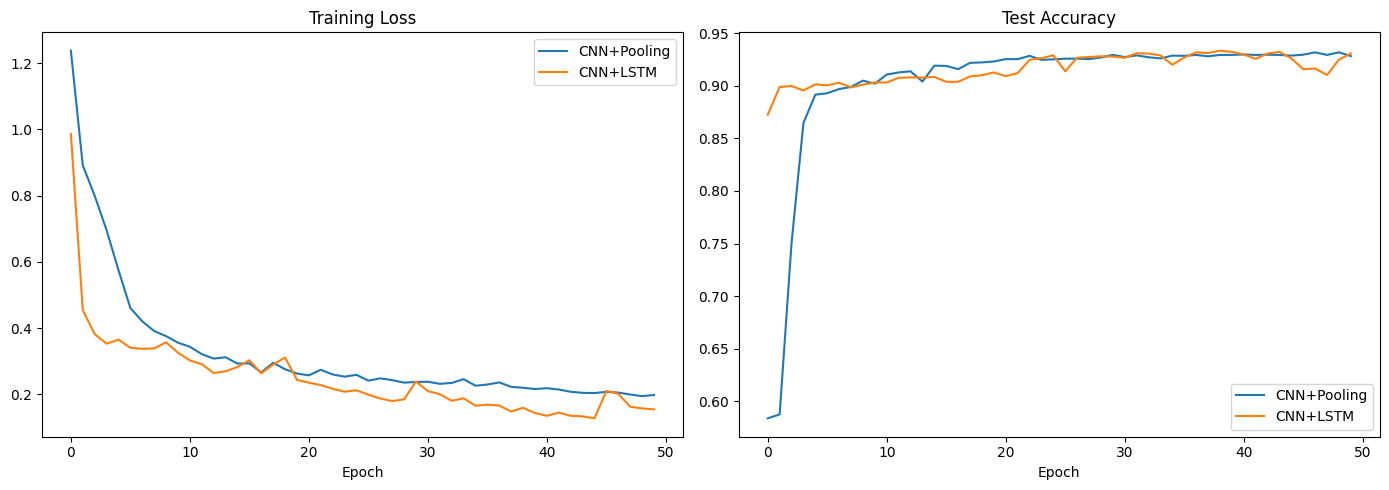


--- Final Results on ECG5000 ---
CNN+Pooling  | Acc: 0.9318 | Time: 49.0s | Params: 35909
CNN+LSTM     | Acc: 0.9333 | Time: 842.5s | Params: 300101


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pool_losses, label='CNN+Pooling')
axes[0].plot(lstm_losses, label='CNN+LSTM')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(pool_accs, label='CNN+Pooling')
axes[1].plot(lstm_accs, label='CNN+LSTM')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n--- Final Results on ECG5000 ---")
print(f"CNN+Pooling  | Acc: {max(pool_accs):.4f} | Time: {pool_time:.1f}s | Params: {sum(p.numel() for p in cnn_pool.parameters())}")
print(f"CNN+LSTM     | Acc: {max(lstm_accs):.4f} | Time: {lstm_time:.1f}s | Params: {sum(p.numel() for p in cnn_lstm.parameters())}")

# Performance vs Sequence Length


Training with sequence length 20...
Epoch 10/50 | Loss: 0.2604 | Acc: 0.9176
Epoch 20/50 | Loss: 0.2015 | Acc: 0.9171
Epoch 30/50 | Loss: 0.1802 | Acc: 0.9147
Epoch 40/50 | Loss: 0.1370 | Acc: 0.9280
Epoch 50/50 | Loss: 0.1405 | Acc: 0.9258
Epoch 10/50 | Loss: 0.3525 | Acc: 0.9033
Epoch 20/50 | Loss: 0.2273 | Acc: 0.9204
Epoch 30/50 | Loss: 0.1741 | Acc: 0.9213
Epoch 40/50 | Loss: 0.1660 | Acc: 0.9229
Epoch 50/50 | Loss: 0.1491 | Acc: 0.9260
Length 20 | CNN+Pooling: 0.9284 | CNN+LSTM: 0.9271

Training with sequence length 40...
Epoch 10/50 | Loss: 0.2834 | Acc: 0.9149
Epoch 20/50 | Loss: 0.2182 | Acc: 0.9149
Epoch 30/50 | Loss: 0.2008 | Acc: 0.9002
Epoch 40/50 | Loss: 0.1571 | Acc: 0.9227
Epoch 50/50 | Loss: 0.1543 | Acc: 0.9264
Epoch 10/50 | Loss: 0.4549 | Acc: 0.8344
Epoch 20/50 | Loss: 0.3166 | Acc: 0.8656
Epoch 30/50 | Loss: 0.2623 | Acc: 0.8560
Epoch 40/50 | Loss: 0.1805 | Acc: 0.8827
Epoch 50/50 | Loss: 0.1590 | Acc: 0.8836
Length 40 | CNN+Pooling: 0.9269 | CNN+LSTM: 0.8884

Tra

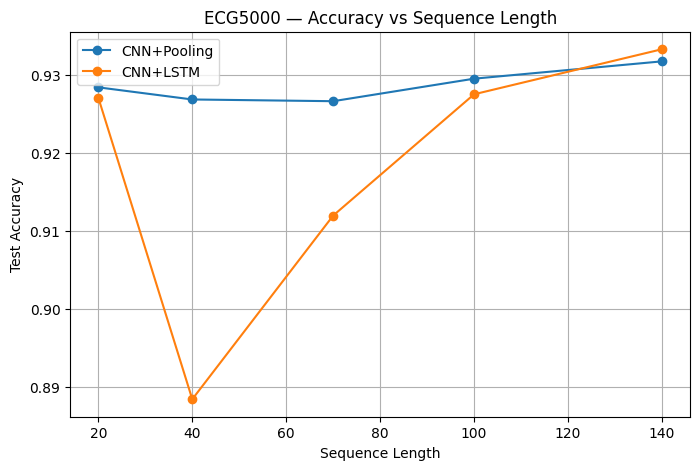

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lengths = [20, 40, 70, 100, 140]
pool_length_accs = []
lstm_length_accs = []

for length in lengths:
    print(f"\nTraining with sequence length {length}...")

    # Truncate
    X_train_short = X_train[:, :, :length]
    X_test_short  = X_test[:, :, :length]

    train_loader_s = DataLoader(TensorDataset(X_train_short, y_train), batch_size=32, shuffle=True)
    test_loader_s  = DataLoader(TensorDataset(X_test_short, y_test),   batch_size=32, shuffle=False)

    # CNN+Pooling
    set_seed(789)
    model_pool = CNN_TemporalPooling(NUM_CLASSES).to(device)
    _, accs_pool, _ = train_model(model_pool, train_loader_s, test_loader_s, epochs=50)
    pool_length_accs.append(max(accs_pool))

    # CNN+LSTM
    set_seed(789A)
    model_lstm = CNN_LSTM(NUM_CLASSES).to(device)
    _, accs_lstm, _ = train_model(model_lstm, train_loader_s, test_loader_s, epochs=50)
    lstm_length_accs.append(max(accs_lstm))

    print(f"Length {length} | CNN+Pooling: {pool_length_accs[-1]:.4f} | CNN+LSTM: {lstm_length_accs[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lengths, pool_length_accs, marker='o', label='CNN+Pooling')
plt.plot(lengths, lstm_length_accs, marker='o', label='CNN+LSTM')
plt.xlabel('Sequence Length')
plt.ylabel('Test Accuracy')
plt.title('ECG5000 — Accuracy vs Sequence Length')
plt.legend()
plt.grid(True)
plt.show()

# Performance vs Noise Level

Sigma 0.0 | CNN+Pooling: 0.9282 | CNN+LSTM: 0.9307
Sigma 0.1 | CNN+Pooling: 0.9276 | CNN+LSTM: 0.9309
Sigma 0.3 | CNN+Pooling: 0.9218 | CNN+LSTM: 0.9273
Sigma 0.5 | CNN+Pooling: 0.8976 | CNN+LSTM: 0.9167
Sigma 1.0 | CNN+Pooling: 0.7000 | CNN+LSTM: 0.8907


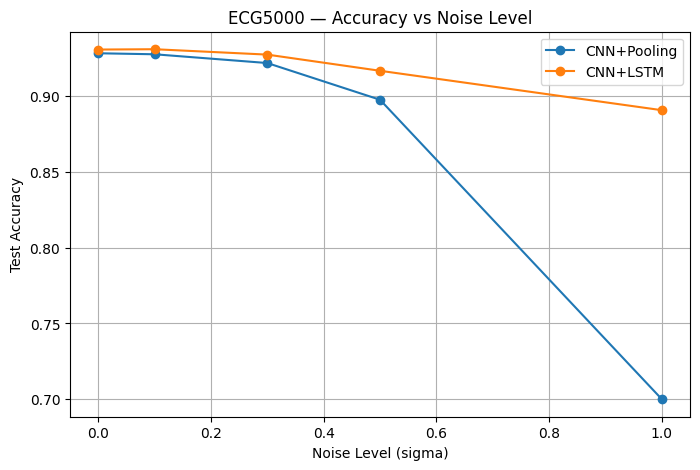

In [23]:
# Use the already trained models from Cell 7 — no retraining needed
# We are testing robustness of learned representations to noise

sigmas = [0.0, 0.1, 0.3, 0.5, 1.0]
pool_noise_accs = []
lstm_noise_accs = []

cnn_pool.eval()
cnn_lstm.eval()

for sigma in sigmas:
    pool_preds, lstm_preds, all_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_noisy = X_batch.to(device) + sigma * torch.randn_like(X_batch).to(device)

            pool_pred = cnn_pool.to(device)(X_noisy).argmax(dim=1).cpu().numpy()
            lstm_pred = cnn_lstm.to(device)(X_noisy).argmax(dim=1).cpu().numpy()

            pool_preds.extend(pool_pred)
            lstm_preds.extend(lstm_pred)
            all_labels.extend(y_batch.numpy())

    pool_noise_accs.append(accuracy_score(all_labels, pool_preds))
    lstm_noise_accs.append(accuracy_score(all_labels, lstm_preds))
    print(f"Sigma {sigma:.1f} | CNN+Pooling: {pool_noise_accs[-1]:.4f} | CNN+LSTM: {lstm_noise_accs[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sigmas, pool_noise_accs, marker='o', label='CNN+Pooling')
plt.plot(sigmas, lstm_noise_accs, marker='o', label='CNN+LSTM')
plt.xlabel('Noise Level (sigma)')
plt.ylabel('Test Accuracy')
plt.title('ECG5000 — Accuracy vs Noise Level')
plt.legend()
plt.grid(True)
plt.show()

# Summary table of all results

In [24]:
print("="*60)
print("FULL RESULTS SUMMARY — ECG5000")
print("="*60)

print("\n1. Baseline")
print(f"   CNN+Pooling : {max(pool_accs):.4f} | {pool_time:.1f}s | {sum(p.numel() for p in cnn_pool.parameters())} params")
print(f"   CNN+LSTM    : {max(lstm_accs):.4f} | {lstm_time:.1f}s | {sum(p.numel() for p in cnn_lstm.parameters())} params")

print("\n2. Accuracy vs Sequence Length")
print(f"   {'Length':<10} {'CNN+Pooling':<15} {'CNN+LSTM'}")
for l, p, q in zip(lengths, pool_length_accs, lstm_length_accs):
    print(f"   {l:<10} {p:<15.4f} {q:.4f}")

print("\n3. Accuracy vs Noise Level")
print(f"   {'Sigma':<10} {'CNN+Pooling':<15} {'CNN+LSTM'}")
for s, p, q in zip(sigmas, pool_noise_accs, lstm_noise_accs):
    print(f"   {s:<10} {p:<15.4f} {q:.4f}")

FULL RESULTS SUMMARY — ECG5000

1. Baseline
   CNN+Pooling : 0.9318 | 49.0s | 35909 params
   CNN+LSTM    : 0.9333 | 842.5s | 300101 params

2. Accuracy vs Sequence Length
   Length     CNN+Pooling     CNN+LSTM
   20         0.9284          0.9271
   40         0.9269          0.8884
   70         0.9267          0.9120
   100        0.9296          0.9276
   140        0.9318          0.9333

3. Accuracy vs Noise Level
   Sigma      CNN+Pooling     CNN+LSTM
   0.0        0.9282          0.9307
   0.1        0.9276          0.9309
   0.3        0.9218          0.9273
   0.5        0.8976          0.9167
   1.0        0.7000          0.8907
